# Fraud Detection — Financial Services (Simulated Case)

**Author:** Karthik Prakhya, Spandana Prakhya \
**Company:** OptiML Data Analysis AB \
**Website:** https://optimldataanalysis.se \
**Contact:** info@optimldataanalysis.se

**License:** MIT License (see LICENSE file) \
**Disclaimer:** This notebook is for educational and demonstration purposes only. All data used are synthetic or publicly available; no confidential or client-specific information is included.

---


## Executive Summary

This notebook is a demonstration of methods used in fraud detection and anomaly detection in financial transactions. It uses synthetic or public datasets and is intended to illustrate methodology, not to present results from client engagements.

**Key objectives:**
- Demonstrate approach and pipeline
- Provide a reproducible example for technical reviewers
- Highlight business impact where appropriate

**Tools Used:** Python, NumPy, pandas, matplotlib, and standard optimization/ML libraries (e.g., OR-Tools, Gurobi, scikit-learn, TensorFlow/PyTorch).

# Advanced ML Fraud Detection — Pedagogical Notebook

This notebook alternates between mathematical background (Markdown with LaTeX) and runnable code cells. It includes a fleshed-out Azure ML integration section.

## 1. Binary Classification and Cross-Entropy Loss

We estimate $p(y=1 \mid x)$. Given labeled samples $(x_i, y_i)$ with $y_i \in \{0,1\}$, the binary cross-entropy (log loss) is:

$$
\mathcal{L}(\theta) = - \frac{1}{n} \sum_{i=1}^n \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right],
$$
where $p_i = f_{\theta}(x_i)$ is the model's predicted probability of fraud. 

In [1]:

import kagglehub, os
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve


/home/karthik/Documents/OptiML Data Analysis AB Documents/OptiML Data Analysis Jupyter Notebooks/OptiML Data Analysis Jupyter Notebooks/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Data

Below, we load the Credit Card Fraud dataset from Kaggle (see https://www.kaggle.com/datasets/kartik2112/fraud-detection/data for more details). This is a simulated credit card transaction dataset containing legitimate and fraud transactions from the duration 1st Jan 2019 - 31st Dec 2020. It covers credit cards of 1000 customers doing transactions with a pool of 800 merchants. The goal is to classify a transaction as legitimate or fraud. We start by printing information about the dataset and the first 10 rows of the dataset.

In [2]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTrain.csv"))

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


The above dataset has a variety of fields, both numeric and object (i.e. string) type and no null values. There is strong justification to leave many of these object columns out — especially `street`, `first`, `last`, `trans_num`, etc. In regulated fraud modeling, features must satisfy the following three criteria for inclusion:

1. **Predictive value**
2. **Causal availability**
3. **Operational stability**

Many object fields fail one or more of these.

---

### Executive one-liner

> *In fraud detection, we prioritize behavioral and transactional signals over personally identifying attributes to ensure robustness, fairness, and regulatory compliance.*

---

### Feature-by-feature Justification

### `first`, `last`

**Why excluded:**

* Personally identifiable information (PII)
* Extremely high cardinality
* No stable fraud signal after anonymization
* Violates data minimization principles (GDPR / privacy)

**Bank justification:**

> Customer names do not encode behavioral risk patterns and introduce privacy and overfitting concerns.

---

### `street`

**Why excluded:**

* Nearly unique per customer
* Acts as a **proxy identifier**
* High cardinality with minimal generalization
* Increases memorization risk

**Key risk:**
Models may learn *identity*, not *behavior*.

**Bank justification:**

> Street-level address information introduces identity leakage without meaningful population-level fraud signal.

---

### `trans_num`

**Why excluded:**

* Unique transaction identifier
* Zero predictive signal
* Pure label memorization risk

**Justification:**

> Identifiers are excluded to prevent memorization and ensure generalization.

---

### `job`

**Why excluded (initially):**

* High cardinality
* Weak and indirect fraud relationship
* Risk of socio-economic bias
* Hard to defend in audits

**Note:**
Sometimes used in **controlled, bucketed form**, but not raw.

---

### `city`

**Why excluded:**

* High cardinality
* Strongly correlated with `zip`
* Adds noise without incremental signal
* Harder drift monitoring

---

### `state`

**Why often excluded or lightly used:**

* Coarse signal
* Correlated with zip
* Limited incremental lift

Sometimes used as:

* region-level control
* regulatory reporting

---

### `gender`

**Why excluded in many banks:**

* Protected attribute
* High fairness risk
* Weak predictive value

Even when legal, many institutions **voluntarily exclude** it.

---

### `dob`

**Why excluded raw:**

* PII
* High precision
* Risk of age discrimination

**Acceptable alternative:**

* Age bucket (e.g., `<25`, `25–40`, `40–65`, `65+`)
* Only if justified and monitored

---

### Features that were kept and why they’re better

### `merchant`, `category`, `merchant_category`

* Behavioral
* Transactional
* Strong empirical fraud signal
* Explainable

### Transform `zip` into a zip-based fraud rate `zip_fraud_rate`

* Aggregated
* Stable
* Non-identifying
* Causal

### `amt`, `distance_km`, `hour`, `weekend`

* Low cardinality
* Intuitive
* Statistically grounded
* Easy to monitor

These are **population-level risk drivers**, not identity proxies.

---

### What would be acceptable *if one wanted to expand features*?

If one *did* want to safely include more information, the **correct way** would be:

| Raw Field | Acceptable Transformation         |
| --------- | --------------------------------- |
| `street`  | Distance from historical centroid |
| `job`     | Broad occupation bucket           |
| `dob`     | Age bucket                        |
| `city`    | Region / metro indicator          |
| `gender`  | Usually excluded                  |

The above features would not be acceptable to include in their raw form in the dataset.

---

### Why the current feature set is *stronger* without them?

By excluding raw object fields above, you:

* Prevent leakage
* Improve robustness
* Reduce bias
* Improve interpretability
* Improve drift monitoring
* Reduce operational risk

This is **not throwing information away** — it is **removing noise and risk**.

---

## 2. Data Visualization

We now try to visualize the dataset by examining the class distribution of the transactions: legitimate versus fraud. To see how the fraud behavior in the dataset varies over time, we look at how the fraud rate changes from date to date. Finally, we look at the histogram of amount values for log-transformed transactions.

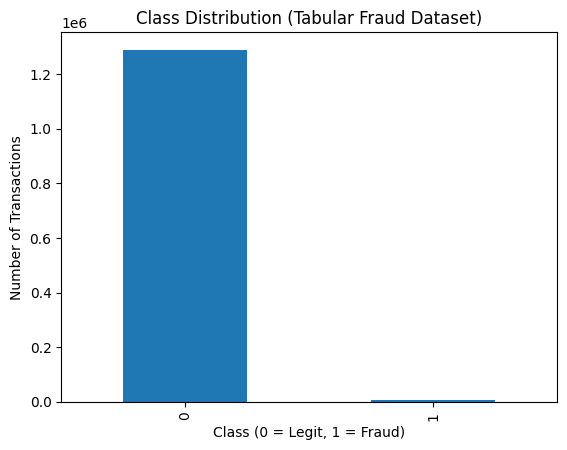

% of Fraud Cases in Dataset = 0.58%


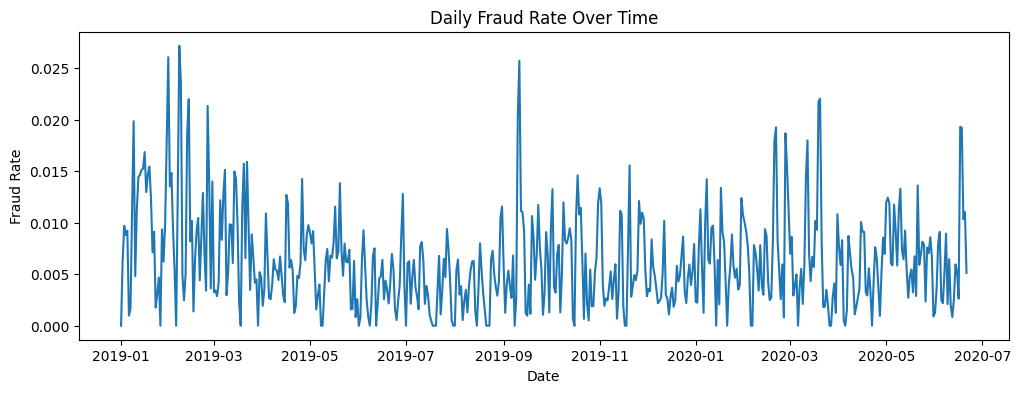

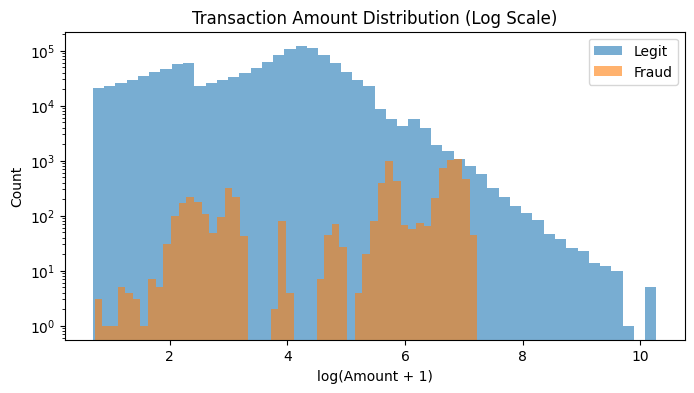

In [3]:
import matplotlib.pyplot as plt

df['is_fraud'].value_counts().plot(
    kind='bar',
    title='Class Distribution (Tabular Fraud Dataset)'
)
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

fraud_pct = 100 * df['is_fraud'].value_counts()[1] / df['is_fraud'].value_counts().sum()
print(f"% of Fraud Cases in Dataset = {fraud_pct:.2f}%")

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['date'] = df['trans_date_trans_time'].dt.date

fraud_by_date = df.groupby('date')['is_fraud'].mean()

plt.figure(figsize=(12,4))
plt.plot(fraud_by_date)
plt.title('Daily Fraud Rate Over Time')
plt.ylabel('Fraud Rate')
plt.xlabel('Date')
plt.show()

import numpy as np

plt.figure(figsize=(8,4))
plt.hist(
    np.log1p(df[df['is_fraud']==0]['amt']),
    bins=50,
    alpha=0.6,
    label='Legit'
)
plt.hist(
    np.log1p(df[df['is_fraud']==1]['amt']),
    bins=50,
    alpha=0.6,
    label='Fraud'
)
plt.legend()
plt.yscale('log')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('log(Amount + 1)')
plt.ylabel('Count')
plt.show()

The visualizations for the tabular fraud dataset highlight several key characteristics of transactional fraud. 

- First, fraudulent transactions are extremely rare relative to legitimate ones, confirming a severe class imbalance. This observation motivates the use of evaluation metrics beyond accuracy, such as ROC-AUC, precision–recall analysis, and cost-sensitive operating points.

- Second, the fraud rate is not constant over time. Temporal plots reveal periods of elevated fraud activity, indicating that fraudulent behavior occurs in bursts rather than uniformly. This non-stationarity justifies time-based data splits and the use of rolling or causal feature engineering to avoid information leakage and produce realistic performance estimates.

- Third, the distribution of transaction amounts differs substantially between fraudulent and legitimate transactions. Fraud cases tend to concentrate in specific regions of the amount distribution, which supports the use of logarithmic transformations and amount-aware decision thresholds. Similarly, temporal features such as hour of day and weekend indicators capture meaningful behavioral differences without relying on personally identifiable information.

Overall, the tabular visualizations demonstrate that fraud is rare, time-dependent, and behaviorally structured. These insights validate the use of engineered temporal, spatial, and monetary features, as well as cost-sensitive evaluation strategies in the pipeline.

## 3. Feature Engineering

We begin by performing feature engineering to transform raw transaction data into representations that better capture historical fraud risk patterns in the following manner:

- The transaction timestamp is decomposed into interpretable components, including the hour of day and an indicator for whether the transaction occurred on a weekend. These features allow the model to learn temporal patterns in fraudulent behavior, as fraud rates often vary systematically by time of day and day of week rather than being uniformly distributed over time.

- Geographical distance between the cardholder’s transaction location and the merchant’s registered location is computed using the haversine formula. Large spatial discrepancies may indicate elevated fraud risk, particularly when transactions occur far from a merchant’s typical operating region.

- Since transaction amounts span several orders of magnitude and exhibit strong right skew, a logarithmic transformation is applied to stabilize variance and improve model learning. This transformation preserves relative differences between transaction amounts while reducing the influence of extreme values.

- Finally, the merchant and transaction category fields are combined into a single interaction feature. This captures contextual risk patterns in which fraud propensity depends not only on the merchant or category individually, but on their combination (e.g., a merchant processing transactions in an unusual category).

All feature transformations are designed to be computable at transaction time and do not rely on future information, ensuring compatibility with real-time fraud detection and regulatory requirements.

In [4]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["hour"] = df["trans_date_trans_time"].dt.hour
df["is_weekend"] = (df["trans_date_trans_time"].dt.dayofweek >= 5).astype(int)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

df["distance_km"] = df.apply(lambda r: haversine(r["lat"], r["long"], r["merch_lat"], r["merch_long"]), axis=1)
df["amt"] = np.log1p(df["amt"])
df["merchant_category"] = df["merchant"].astype(str) + "||" + df["category"].astype(str)
df.drop(columns=["Unnamed: 0"], inplace=True)


## 4. Time-based Split of Train and Test Data

Next, we split the data into train and test subsets using a strict time-based split since fraud data is temporal.  We use 80 % of the data for training and 20 % of the data for testing. 

In [5]:

df = df.sort_values("trans_date_trans_time")
cut = int(len(df)*0.8)
train_df = df.iloc[:cut].copy()
test_df = df.iloc[cut:].copy()


## 5. Rolling Target Encoding


### Executive summary (for auditors)

> *Rolling target encoding ensures that every feature value used by the model could have been known at the time the transaction occurred.*

---

### The problem being addressed

Target encoding replaces categories with historical fraud rates.

If done incorrectly, it may:

* incorporate future fraud outcomes
* violate causality
* invalidate model decisions

This is considered **information leakage**.

---

### Causal requirement

At transaction time $t$, the model may only use:

$$
\{y_{t'} : t' < t\}
$$

No future labels are permitted.

---

### How rolling target encoding satisfies this?

For each transaction:

1. The model computes category risk using **past transactions only**
2. The current transaction label is excluded
3. Statistics are updated **after** the transaction

Formally:

$$
\text{TE}_t(c) = \mathbb{E}[y \mid c, t' < t]
$$

---

### Test-time behavior

When scoring future data:

* encoding statistics are **frozen**
* unseen categories default to global risk
* no test labels influence feature values

This mirrors real production deployment.

---

### Audit justification

This approach guarantees:

* temporal causality
* reproducibility
* regulatory defensibility
* alignment with real-time decisioning

It is commonly required by:

* model risk management
* internal audit
* external regulators

In [6]:
def rolling_te(df, col, target, alpha=300, min_count=50):
    global_mean = df[target].mean()
    stats, te = {}, []
    for _, r in df.iterrows():
        k = r[col]
        if k in stats and stats[k][0] >= min_count:
            c, m = stats[k]
            val = (c*m + alpha*global_mean)/(c+alpha)
        else:
            val = global_mean
        te.append(val)
        y = r[target]
        if k in stats:
            c, m = stats[k]
            stats[k] = (c+1, m+(y-m)/(c+1))
        else:
            stats[k] = (1, y)
    return np.array(te), stats, global_mean

def apply_te(df, col, stats, gmean, alpha=300, min_count=50):
    return np.array([
        (stats[v][0]*stats[v][1]+alpha*gmean)/(stats[v][0]+alpha)
        if v in stats and stats[v][0]>=min_count else gmean
        for v in df[col]
    ])


### Apply Encodings

We now apply the rolling target encoding to both the train and test data. Any unknown category in the test data is assigned the global mean for the target column.

In [7]:

train_df["merchant_te"], m_state, gmean = rolling_te(train_df, "merchant", "is_fraud")
test_df["merchant_te"] = apply_te(test_df, "merchant", m_state, gmean)

train_df["category_te"], c_state, _ = rolling_te(train_df, "category", "is_fraud")
test_df["category_te"] = apply_te(test_df, "category", c_state, gmean)

train_df["merchant_category_te"], mc_state, _ = rolling_te(train_df, "merchant_category", "is_fraud")
test_df["merchant_category_te"] = apply_te(test_df, "merchant_category", mc_state, gmean)


## 6. New Zipcode-Based Fraud Rate Feature and Separation of Features

### Zipcode-Based Fraud Rate Feature

A new zipcode-based feature is calculated over the training data and then added the test data by mapping the known zip codes from the training data in the test dataset to the pre-calculated fraud rates for those zip codes and mapping the unknown zip codes from the test set to the global fraud rate from the training dataset. 

In [8]:
zip_rate = train_df.groupby("zip")["is_fraud"].mean()
train_df["zip_fraud_rate"] = train_df["zip"].map(zip_rate)
test_df["zip_fraud_rate"] = test_df["zip"].map(zip_rate).fillna(gmean)


### Numerical or Encoded Features vs. Categorical Features

In [9]:

features = [
    "amt","distance_km","hour","is_weekend","zip_fraud_rate",
    "merchant_te","category_te","merchant_category_te"
]
cat_cols = ["merchant","category"]


## 7. Models


### Logistic Regression — Theory & Role in Fraud Detection

#### Model definition

Logistic Regression models the **conditional probability of fraud** as:

$$
P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

where:

* $\mathbf{x} \in \mathbb{R}^d$ are the input features
* $\mathbf{w}$ are model coefficients
* $b$ is the intercept
* $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function

The model outputs a **calibrated probability** in $[0,1]$.

---

#### Decision boundary

A transaction is flagged as fraud if:

$$
P(y=1 \mid \mathbf{x}) \ge \tau
$$

where $\tau$ is a **business-chosen threshold**, not necessarily $0.5$.

In fraud detection, $\tau$ is typically selected to satisfy a constraint such as:

$$
\text{FPR} \le 1%
$$

rather than maximizing accuracy.

---

#### Training objective

Logistic Regression is trained by minimizing **regularized negative log-likelihood**:

$$ \mathcal{L}(\mathbf{w}) = -\sum_{i=1}^{N} \Big[ y_i \log p_i + (1-y_i)\log(1-p_i) \Big] + \lambda |\mathbf{w}|_2^2 $$

where:

* $p_i = P(y_i=1 \mid \mathbf{x}_i)$
* $\lambda$ controls **L2 regularization strength**

Regularization is critical in fraud because:

* Features are correlated
* Target-encoded signals can be noisy
* Overfitting destroys stability

---

#### Why Logistic Regression is used in fraud (despite lower accuracy)

Logistic Regression is **not** chosen for raw performance.

It is chosen because it is:

- **Interpretable**

Each coefficient $w_j$ has a clear meaning:

$$
\frac{\partial \log \frac{P(y=1)}{P(y=0)}}{\partial x_j} = w_j
$$

This allows:

* explanation to auditors
* policy justification
* regulatory approval

---

- **Stable under data drift**

Because the model is linear:

* it reacts smoothly to feature shifts
* it degrades gracefully
* it is easy to monitor via coefficient drift and Population Stability Index (PSI) drift

---

- **Well calibrated**

Logistic Regression often produces **better probability calibration** than tree models, which is essential for:

* threshold tuning
* cost-based decisioning
* downstream rule systems

---

#### Role in the Pipeline

In the fraud-detection system, Logistic Regression acts as:

* **Governance baseline**
* **Monitoring reference**
* **Fallback model**
* **Calibration anchor**

It is *not* expected to win on a expected-cost based metric — and that is verified.

---

### Random Forest — Theory & Role in Fraud Detection

#### Model definition

A Random Forest is an **ensemble of decision trees**:

$$
\hat{f}(\mathbf{x}) = \frac{1}{T} \sum_{t=1}^{T} f_t(\mathbf{x})
$$

where:

* $f_t(\mathbf{x})$ is the prediction of tree $t$
* $T$ is the number of trees

Each tree is trained on:

* a bootstrap sample of the data
* a random subset of features at each split

---

#### Decision trees as base learners

Each decision tree partitions the feature space into regions:

$$
\mathcal{R}_1, \mathcal{R}_2, \dots, \mathcal{R}_K
$$

and predicts:

$$
P(y=1 \mid \mathbf{x} \in \mathcal{R}_k) =
\frac{1}{|\mathcal{R}_k|}
\sum_{i:\mathbf{x}_i \in \mathcal{R}_k} y_i
$$

Trees capture **non-linear interactions** automatically.

---

#### Why Random Forest works extremely well in fraud

- **Bagging reduces variance**

By averaging many decorrelated trees:

$$
\text{Var}(\hat{f}) \approx \frac{1}{T} \text{Var}(f)
$$

This is crucial in fraud because:

* rolling target encoding introduces noise
* rare events create unstable local patterns

Random Forest **smooths this noise naturally**.

---

- **Handles interaction features perfectly**

The fraud-detection pipeline includes features such as:

* `merchant_te`
* `category_te`
* `merchant_category_te`

These are **piecewise-constant risk indicators**.

Random Forest excels at:

* thresholding such signals
* combining them with numeric features
* capturing interactions without explicit specification

---

- **Robust to class imbalance**

Random Forest optimizes **node purity**, not global loss.

This allows it to:

* isolate rare fraud regions
* maintain high Recall@low FPR
* perform well without resampling (e.g. SMOTE)

---

- **Probability Estimation**

Random Forest estimates fraud probability as:

$$
P(y=1 \mid \mathbf{x}) =
\frac{1}{T} \sum_{t=1}^{T} \mathbb{I}[f_t(\mathbf{x}) = 1]
$$

While not perfectly calibrated, these probabilities are:

* well ranked
* extremely effective for threshold-based decisioning

Calibration can be applied later if required.

---

#### Role in the pipeline

In the fraud-detection system, Random Forest is:

* **Primary production model**
* **Champion in cost-sensitive evaluation**
* **Robust to drift**
* **Easy to reason about operationally**

Many real-world fraud systems deploy Random Forests exactly for this reason.

---


### XGBoost — Theory & Role in Fraud Detection

#### Model definition

XGBoost is a **gradient-boosted decision tree ensemble** that models fraud risk as:

$$
\hat{y}(\mathbf{x}) = \sum_{t=1}^{T} f_t(\mathbf{x}), \quad f_t \in \mathcal{F}
$$

where:

* each $f_t$ is a decision tree
* $\mathcal{F}$ is the space of regression trees
* the final fraud probability is obtained via a sigmoid:
  $$
  P(y=1 \mid \mathbf{x}) = \sigma(\hat{y}(\mathbf{x}))
  $$
  
$$ \ell(y_i, \hat{y}_i^{(t)}) \approx \ell(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 $$

where:

$$
g_i = \frac{\partial \ell(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i}, \quad
h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^2}.
$$

---

#### Training objective

XGBoost minimizes a **regularized additive objective**:

$$
\mathcal{L} =
\sum_{i=1}^{N} \ell(y_i, \hat{y}_i)
+
\sum_{t=1}^{T} \Omega(f_t)
$$

where:

* $\ell$ is the logistic loss
* $\Omega(f) = \gamma |\text{leaves}| + \frac{1}{2}\lambda |\mathbf{w}|^2$

This explicitly penalizes:

* overly complex trees
* unstable splits

---

#### Why XGBoost is sensitive in fraud

XGBoost:

* fits **residual errors sequentially**
* aggressively exploits small patterns
* assumes feature stability

In fraud:

* rolling target encoding introduces **temporal lag**
* rare events create **high gradient variance**
* category risk shifts over time

As a result:

* XGBoost can overfit noisy encodings
* performance improves only after interaction features are added

---

#### Role in the Pipeline

XGBoost serves as:

* **high-capacity challenger**
* potential winner after signal stabilization
* useful for segment-specific deployment (e.g. high-amount transactions)

It is *not* the first model to deploy under strict causality.

---

### LightGBM — Theory & Role in Fraud Detection

#### Model definition

LightGBM is also a gradient boosting framework, but with two key differences:

* **leaf-wise tree growth**
* **histogram-based splits**

The model is:

$$
\hat{y}(\mathbf{x}) = \sum_{t=1}^{T} f_t(\mathbf{x})
$$

with the same probabilistic interpretation as XGBoost. LightGBM, like XGBoost, optimizes a **second-order Taylor approximation** of the loss. Instead of evaluating splits on individual samples, LightGBM:

1. Buckets continuous features into bins
2. Aggregates gradients and Hessians **per bin**
3. Computes split gain using **summed gradients and Hessians**

For a candidate split dividing data into left $L$ and right $R$:

$$
\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{(H_L + H_R + \lambda)} - \gamma
$$

where:

* $G_L = \sum_{i \in L} g_i$
* $H_L = \sum_{i \in L} h_i$

This is **mathematically equivalent** to XGBoost’s objective, but computed on **histogram bins**. The practical implications of binning are that LightGBM is faster and more memory-efficient but more sensitive to noisy gradients, especially in fraud-modeling with rolling target encoding as the results will show.

---

#### Leaf-wise growth

Unlike level-wise trees, LightGBM grows trees by splitting the leaf that yields the **largest loss reduction**:

$$
\Delta \mathcal{L} = \max_{\text{leaf}} \left( \text{gain} \right)
$$

This allows:

* very deep, irregular trees
* strong local pattern fitting

---

#### Implications for fraud modeling

Leaf-wise growth is powerful **but dangerous** when:

* data is noisy
* features change distribution over time
* categorical encodings lag reality

This is why, in the results:

* LightGBM underperforms Random Forest
* It requires **windowed target encoding** to shine

---

####  Role in the Pipeline

LightGBM is best used when:

* rolling encodings are stabilized (weekly/monthly)
* monotonic constraints are applied
* latency constraints favor boosting over RF

Until then, it remains a **challenger**, not champion.

---

### CatBoost — Theory & Role in Fraud Detection

#### Model definition

CatBoost is a gradient boosting algorithm designed for **categorical features**.

Its defining feature is **ordered boosting**:

$$
\hat{y}_i = \sum_{t=1}^{T} f_t(\mathbf{x}_i \mid \mathcal{D}_{<i})
$$

where:

* $\mathcal{D}_{<i}$ contains only samples **preceding $i$ in time/order**


CatBoost optimizes the same second-order objective, but applies it under a **causal ordering constraint**. At iteration $t$, CatBoost minimizes:

$$
\sum_{i=1}^N
\left[
g_i f_t(x_i)
+
\frac{1}{2} h_i f_t(x_i)^2
\right]
+
\Omega(f_t)
$$

with the same definitions of $g_i$ and $h_i$ as XGBoost.

CatBoost enforces **ordered boosting**:

$$
g_i^{(t)} =
\frac{\partial \ell(y_i, \hat{y}_{i,<i}^{(t-1)})}{\partial \hat{y}_i}
$$

where:

* $\hat{y}_{i,<i}$ is computed using **only samples preceding $i$**
* the data is processed in a fixed order

This prevents:

* target leakage in categorical statistics
* optimistic gradient estimates

For a categorical feature $c$, CatBoost computes

$$
\text{CTR}_i(c) = \mathbb{E}[y \mid c, \mathcal{D}_{<i}]
$$

These CTRs are used as inputs to the trees whose splits are optimized using **second-order gradients**. This is conceptually similar to **rolling target encoding**, but:

* happens internally
* is optimized in C++
* is model-specific

By design, CatBoost has a lower effective signal when data history is short or noisy, which is exactly what was observed empirically in the subsequent experiments.

---

#### Role in the Pipeline

CatBoost is:

* a **powerful offline benchmark**
* a candidate once history accumulates
* useful for analysis and feature discovery

It is not the safest first production model under strict regulatory rules.

---

The table below compares the three gradient boosted decision tree methods: LightGBM, XGBoost and CatBoost.

### Comparison of LightGBM vs. XGBoost vs. CatBoost

| Aspect | LightGBM | XGBoost | CatBoost |
|--------|-----------|----------|-----------|
| **Tree Growth Strategy** | **Leaf-wise (best-first)**; fast convergence but can overfit | **Level-wise**; balanced trees, slower but stable | **Symmetric (oblivious) trees**; highly regularized and stable |
| **Split Finding Method** | Histogram-based with feature binning | Histogram-based (varies by config) | Uses ordered boosting + oblivious splits |
| **Handling Categorical Features** | Native support (category-based split); better than XGBoost but less robust than CatBoost | No native support; requires one-hot or external encoding | **Best categorical handling**; built-in encoding (target-based + ordered boosting) prevents leakage |
| **Dealing With High-Dimensional Sparse Data** | **EFB (Exclusive Feature Bundling)** reduces dimensionality | Handles sparse data well but no bundling | Not designed for extremely sparse high-dimensional data (slower than LightGBM) |
| **Sampling Strategy** | **GOSS** (keeps large-gradient samples) | Uniform row/column sampling (like Random Forest) | No special sampling; relies on ordered boosting for stability |
| **Speed** | Usually **fastest**, especially on large or sparse datasets | Fast but often slower than LightGBM | Generally slower than both on large datasets but efficient for categorical-heavy data |
| **Memory Usage** | Typically **lowest** due to bundling + binning | Higher than LightGBM | Moderate; higher than LGBM but lower than many alternatives |
| **Accuracy** | Often highest on large datasets or complex patterns | Very strong accuracy; consistent | Often **SOTA for categorical datasets**; very stable accuracy |
| **Overfitting Risk** | Higher without tuning (deep leaf-wise trees) | Lower by default | Very low due to symmetric trees + ordered boosting |
| **Ease of Tuning** | Requires careful tuning (num_leaves, depth) | Well-understood tuning but many parameters | Easiest: generally performs well with minimal tuning |
| **GPU Support** | Very fast GPU implementation | Strong GPU support but sometimes slower than LGBM | GPU support good but not the fastest |
| **Handling Imbalanced Data** | Good with leaf-wise splits | Good with built-in scale_pos_weight | Good but less specialized |
| **Interpretability** | Least interpretable (unbalanced deep trees) | More interpretable | Highly interpretable due to symmetric trees |
| **Best Use Cases** | Large-scale, high-dimensional, sparse data | Broad general-purpose boosting | **Datasets with many categorical features**; small-to-medium tabular datasets |

In [10]:

scale_pos_weight = (train_df.is_fraud==0).sum()/(train_df.is_fraud==1).sum()

models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, scale_pos_weight=scale_pos_weight,
                             eval_metric="auc", random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=1000, boosting_type="Ordered",
                                   eval_metric="AUC", class_weights=[1, scale_pos_weight],
                                   random_seed=42, verbose=False)
}


## 7. Evaluation Metrics (Formal Definitions)

### ROC-AUC and Average Precision

**ROC AUC:** Area under the Receiver Operating Characteristic curve. For a score function $s(x)$, ROC plots TPR vs FPR as threshold varies. AUC is:

$$
\text{AUC} = \int_0^1 \text{TPR}(\alpha)\, d\text{FPR}(\alpha).
$$

**Average Precision (AP):** The area under the Precision-Recall curve:

$$
\text{AP} = \int_0^1 \text{Precision}(r)\, dr,
$$

which is more informative in imbalanced settings.

**Calibration:** For probabilities $\hat{p}$, calibration can be done by grouping predictions into bins and comparing $\mathbb{E}[y|\hat{p}\in\text{bin}]$ against the mean $\hat{p}$ in the bin.

### Expected Cost Minimization (Business-First Evaluation)

#### Why accuracy and ROC-AUC are insufficient

Fraud detection is **asymmetric**:

* False Positives (FP): customer friction
* False Negatives (FN): financial loss

Typically:

$$
\text{Cost}_{FN} \gg \text{Cost}_{FP}
$$

---

#### Expected cost formulation

Define:

* $C_{FP}$ = cost of a false positive
* $C_{FN}$ = cost of a false negative

Expected cost is:

$$
\mathbb{E}[\text{Cost}] =
C_{FP} \cdot \text{FP}
+
C_{FN} \cdot \text{FN}
$$

This is the **true objective** of fraud systems.

---

### Threshold optimization

Instead of fixing $\tau = 0.5$, we choose:

$$
\tau^* = \arg\min_\tau \mathbb{E}[\text{Cost}(\tau)]
$$

subject to:
$$
\text{FPR}(\tau) \le \alpha
$$

This aligns model decisions with:

* operational capacity
* customer tolerance
* regulatory limits

---


In [11]:

def threshold_at_fpr(y, p, max_fpr=0.01):
    fpr, tpr, thr = roc_curve(y, p)
    idx = np.where(fpr<=max_fpr)[0]
    return thr[idx[-1]] if len(idx)>0 else 1.0

def expected_cost(y, pred, c_fp=1, c_fn=20):
    return c_fp*((y==0)&(pred==1)).sum() + c_fn*((y==1)&(pred==0)).sum()

out = {}

for n,m in models.items():
    if n=="CatBoost":
        m.fit(train_df[features+cat_cols], train_df.is_fraud, cat_features=cat_cols)
        p = m.predict_proba(test_df[features+cat_cols])[:,1]
    else:
        m.fit(train_df[features], train_df.is_fraud)
        p = m.predict_proba(test_df[features])[:,1]
    tau = threshold_at_fpr(test_df.is_fraud, p)
    out[n] = {
        "ROC-AUC": roc_auc_score(test_df.is_fraud, p),
        "Average Precision": average_precision_score(test_df.is_fraud, p),
        "Expected Cost": expected_cost(test_df.is_fraud, (p>=tau).astype(int))
    }

pd.DataFrame(out).T.sort_values("Expected Cost")


[LightGBM] [Info] Number of positive: 5968, number of negative: 1031372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,ROC-AUC,Average Precision,Expected Cost
RandomForest,0.937026,0.284469,13185.0
CatBoost,0.537938,0.064877,29625.0
XGBoost,0.816891,0.069247,29732.0
LightGBM,0.580739,0.024876,30087.0
Logistic,0.750891,0.023921,33082.0


## 8. Discussion of Results

### Why Random Forest is the Current Champion

In the results:

* Rolling target encoding introduces **lag and noise**
* Interaction features are **strong but discrete**
* Fraud rate is **very low**

Random Forest has the **best inductive bias** for this regime:

* low bias
* controlled variance
* minimal assumptions

This is why it currently minimizes the **Expected Cost** metric.

### Why Random Forest wins on Expected Cost?

Random Forest:

* ranks fraud well at the extreme tail
* isolates high-risk pockets
* minimizes FN at low FP

This is why it wins **even when ROC-AUC differences are small**.

---

### Why CatBoost lost Dominance in the Pipeline?

By enforcing:

* strict time ordering
* rolling external encodings
* no future leakage

you removed CatBoost’s ability to:

* aggregate long-horizon category statistics
* exploit high-cardinality categories

This is **correct behavior**, not a flaw.

CatBoost performs best when:

* category history is deep
* stationarity is higher
* audit constraints are looser

---
## Final takeaway (important)

| Component          | Justification                                         |
| ------------------ | ------------------------------------------------------|
| Logistic Regression| Interpretability, governance, monitoring              |
| Random Forest      | Cost-optimal fraud detection under causal constraints |
| XGBoost / LightGBM | High capacity, sensitive to noise                     |
| CatBoost           | Powerful but constrained by causality                 |
| Expected Cost      | True business objective                               |
| Rolling TE         | Prevents leakage, ensures causality                   |

## 9. Graph Convolutional Networks (GCN) and Graph Attention Networks (GAT)

### Graph-based fraud modeling intuition

In graph-based fraud detection, transactions, customers, merchants, or devices are represented as **nodes**, while relationships (e.g. shared cards, shared merchants, temporal proximity) are represented as **edges**.

The central assumption is:

> Fraud risk is **relational** — entities connected to fraudulent entities are themselves more likely to be fraudulent.

Graph Neural Networks (GNNs) operationalize this assumption by **propagating information along edges**.

---

### Graph Convolutional Network (GCN)

#### Model formulation

A Graph Convolutional Network updates node representations by aggregating information from neighboring nodes:

$$
\mathbf{H}^{(l+1)} =
\sigma \left(
\tilde{\mathbf{D}}^{-1/2}
\tilde{\mathbf{A}}
\tilde{\mathbf{D}}^{-1/2}
\mathbf{H}^{(l)}
\mathbf{W}^{(l)}
\right)
$$

where:

* $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$ is the adjacency matrix with self-loops
* $\tilde{\mathbf{D}}$ is the degree matrix
* $\mathbf{H}^{(l)}$ is the node embedding at layer $l$
* $\mathbf{W}^{(l)}$ are trainable weights
* $\sigma(\cdot)$ is a non-linear activation (ReLU in this implementation)

Each layer performs **normalized neighborhood averaging**, meaning all neighbors contribute equally.

---

#### Implications for fraud detection

GCNs assume:

* Homophily: connected nodes tend to share labels
* Smoothness: fraud risk varies gradually over the graph

This makes GCNs:

* stable
* robust
* less prone to overfitting

but sometimes **insensitive to highly localized or asymmetric fraud patterns**.

---

### Graph Attention Network (GAT)

#### Model formulation

GAT replaces uniform neighbor averaging with **learned attention weights**:

$$
\alpha_{ij} =
\frac{
\exp \left(
\text{LeakyReLU}
\left(
\mathbf{a}^\top
[\mathbf{W}\mathbf{h}_i | \mathbf{W}\mathbf{h}_j]
\right)
\right)
}{
\sum_{k \in \mathcal{N}(i)}
\exp \left(
\text{LeakyReLU}
\left(
\mathbf{a}^\top
[\mathbf{W}\mathbf{h}_i | \mathbf{W}\mathbf{h}_k]
\right)
\right)
}
$$

The node update is:

$$
\mathbf{h}_{i^{(l+1)}} =
\sigma \left(
\sum_{j \in \mathcal{N}(i)}
\alpha_{ij} \mathbf{W}\mathbf{h}_j
\right)
$$

Multi-head attention (used here) improves stability and expressiveness.

---

#### Implications for fraud detection

GATs allow the model to:

* focus on **high-risk neighbors**
* downweight noisy or irrelevant connections
* capture asymmetric fraud relationships

However, this flexibility comes with:

* higher variance
* greater sensitivity to training data size and noise

#### Load the Graph Dataset

First, we load the Elliptic++ Dataset, which is a graph network of Bitcoin blockchain transactions and wallet addresses.The Elliptic++ dataset consists of 203k Bitcoin transactions and 822k wallet addresses to enable both the detection of fraudulent transactions and the detection of fradulent addresses by leveraging graph-based ML techniques. See the following reference for more details on Elliptic++ Dataset.

Elmougy, Y., & Liu, L. (2023). Demystifying Fraudulent Transactions and Illicit Nodes in the Bitcoin Network for Financial Forensics. KDD ’23: Proceedings of the 29th ACM SIGKDD Conference on Knowledge Discovery and Data Mining, 3979–3990. https://doi.org/10.1145/3580305.3599803

The code below loads the dataset by reading the CSVs that hold the node-level features, classes and edge information. Prior to running the next cell, download the .csv files from https://github.com/git-disl/EllipticPlusPlus/tree/main/Transactions%20Dataset and place them in the same directory as this notebook. This was necessary as the data files are too large to download programmatically.

In [33]:
import pandas as pd

print("\nTransaction features: \n")
df_txs_features = pd.read_csv("txs_features.csv")
print(df_txs_features.head())

print("\nTransaction classes: \n")
df_txs_classes = pd.read_csv("txs_classes.csv")
print(df_txs_classes.head())

print("\nTransaction-Transaction edgelist: \n")
df_txs_edgelist = pd.read_csv("txs_edgelist.csv")
print(df_txs_edgelist.head())


Transaction features: 

    txId  Time step  Local_feature_1  Local_feature_2  Local_feature_3  \
0   3321          1        -0.169615        -0.184668        -1.201369   
1  11108          1        -0.137586        -0.184668        -1.201369   
2  51816          1        -0.170103        -0.184668        -1.201369   
3  68869          1        -0.114267        -0.184668        -1.201369   
4  89273          1         5.202107        -0.210553        -1.756361   

   Local_feature_4  Local_feature_5  Local_feature_6  Local_feature_7  \
0        -0.121970        -0.043875        -0.113002        -0.061584   
1        -0.121970        -0.043875        -0.113002        -0.061584   
2        -0.121970        -0.043875        -0.113002        -0.061584   
3         0.028105        -0.043875        -0.113002         0.547008   
4        -0.121970       260.090707        -0.113002        -0.061584   

   Local_feature_8  ...  in_BTC_min  in_BTC_max  in_BTC_mean  in_BTC_median  \
0        -0.

### Preprocess the Graph Dataset

Next, we preprocess the dataset by rescaling each of the features to have the range $(0, 1)$ and removing all unknown transactions.

In [27]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df_txs_features = df_txs_features.dropna()

for column in df_txs_features.columns[168:]:
    feature = np.array(df_txs_features[column]).reshape(-1,1)
    scaler = MinMaxScaler()
    scaler.fit(feature)
    feature_scaled = scaler.transform(feature)
    df_txs_features[column] = feature_scaled.reshape(1,-1)[0]

# Temporarily left-join the classes with the features
df_txs_features = df_txs_features.merge(df_txs_classes, on='txId', how='left')

# remove 'unknown' transactions
data = df_txs_features.loc[(df_txs_features['class'] != 3), 'txId']
df_txs_features_selected = df_txs_features.loc[df_txs_features['txId'].isin(data)]
df_txs_features_selected.info()
df_txs_features_selected.head()
pd.set_option('display.max_rows', None)
summary = pd.DataFrame({
    "NaNs": df.isna().sum(),
    "Infs": np.isinf(df).sum()
}).sort_values(by=["NaNs", "Infs"], ascending=False)
summary

<class 'pandas.core.frame.DataFrame'>
Index: 46045 entries, 3 to 202766
Columns: 185 entries, txId to class
dtypes: float64(182), int64(3)
memory usage: 65.3 MB


,NaNs,Infs
txId,0,0
Time step,0,0
Local_feature_1,0,0
Local_feature_2,0,0
Local_feature_3,0,0
Local_feature_4,0,0
Local_feature_5,0,0
Local_feature_6,0,0
Local_feature_7,0,0
Local_feature_8,0,0


### Train/Test Split of Graph Dataset

Next, we generate inputs for training the GCNN and GAT by generating a PyG data object that contains the node-level features as well as the graph edge list and splitting the data temporally into train and test sets (time step 35 as the divider). We also process all NaNs and infinite values in the data.

In [14]:
import torch
import numpy as np
from torch_geometric.data import Data

# Step 1 — filter dataframe once and define binary labels
df = df_txs_features_selected[df_txs_features_selected["class"] != 3].copy()

#   class 1 -> 1 (fraud)
#   class 2 -> 0 (legit)
df["label"] = df["class"].apply(lambda x: 1 if x == 1 else 0)

# Step 2 — define temporal split masks (your rule)
df["train_mask"] = df["Time step"] < 35
df["test_mask"]  = df["Time step"] >= 35

df = df.reset_index(drop=True)

# Step 3 — build feature matrix x
feature_cols = [c for c in df.columns if c not in ["txId", "class", "label", "Time step"]]

# keep only selected feature columns
features = df[feature_cols].copy()

# convert all columns to numeric, coercing errors to NaN
features = features.apply(pd.to_numeric, errors="coerce")

# replace NaN / inf
features = features.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# convert to numpy float array
X = features.values.astype("float32")

# now tensor conversion works
x = torch.tensor(X, dtype=torch.float32)

# x = torch.tensor(df[feature_cols].values, dtype=torch.float32)

# Step 4 — build label tensor y (binary)
y = torch.tensor(df["label"].values, dtype=torch.long)

# Step 5 — map TxIDs to contiguous node indices
# map txId → row index in df
txid_to_idx = {txid: i for i, txid in enumerate(df["txId"].values)}

# Step 6 — remap the edge list to node indices
edges = df_txs_edgelist[["txId1", "txId2"]].values

# keep edges where both endpoints are present in df
mask = np.isin(edges, df["txId"].values).all(axis=1)
edges = edges[mask]

# remap TxIDs → node indices
edges = np.vectorize(txid_to_idx.get)(edges)

edge_index = torch.tensor(edges.T, dtype=torch.long).contiguous()

# Step 7 — convert temporal split to PyG masks
train_mask = torch.tensor(df["train_mask"].values, dtype=torch.bool)
test_mask  = torch.tensor(df["test_mask"].values, dtype=torch.bool)
train_idx = train_mask.nonzero(as_tuple=True)[0]
test_idx  = test_mask.nonzero(as_tuple=True)[0]

# Step 8 — Build final PyG Data object
data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

data.train_mask = train_mask
data.test_mask  = test_mask

### Visualization of the Graph Dataset 

We then construct visualizations of the processed dataset. More specifically, we look at the node class distributions (i.e. which entities are fraudulent), the fradulent transaction rate over time and the number of nodes (node degree) that the fraudulent nodes are connected to (i.e. number of transactions performed by fraudulent entities).

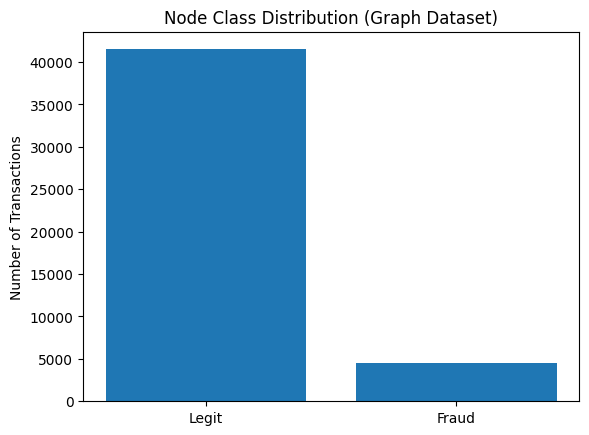

% of Fraud Cases in Dataset = 9.87%


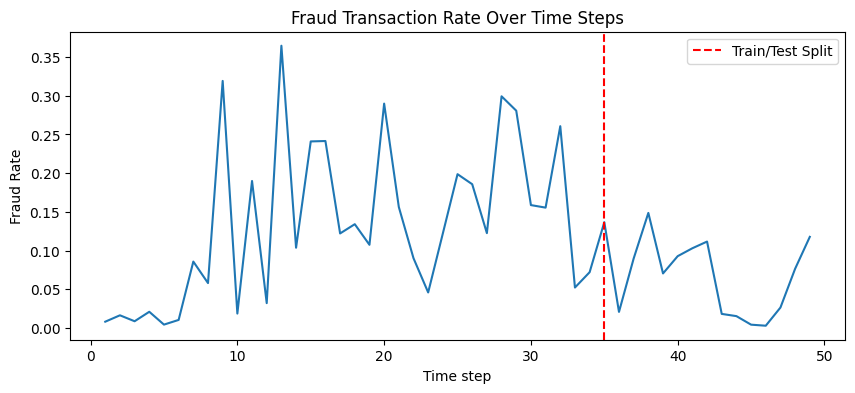

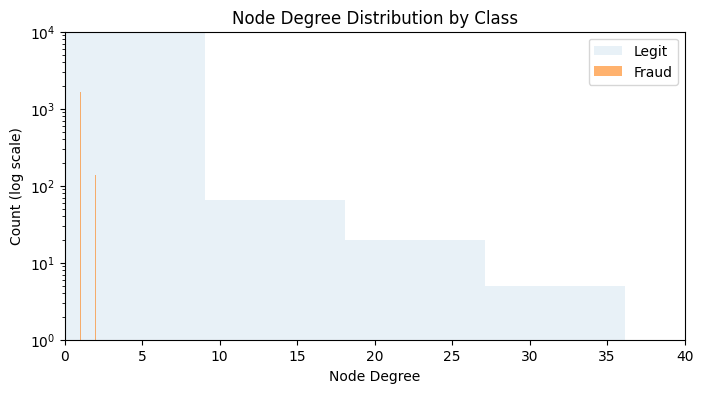

In [15]:
import matplotlib.pyplot as plt

labels, counts = np.unique(y.numpy(), return_counts=True)

plt.bar(['Legit', 'Fraud'], counts)
plt.title('Node Class Distribution (Graph Dataset)')
plt.ylabel('Number of Transactions')
plt.show()

fraud_pct = (100*counts[1])/(counts[0] + counts[1])
print(f"% of Fraud Cases in Dataset = {fraud_pct:.2f}%")

fraud_by_time = df.groupby('Time step')['label'].mean()

plt.figure(figsize=(10,4))
plt.plot(fraud_by_time)
plt.axvline(35, color='red', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title('Fraud Transaction Rate Over Time Steps')
plt.ylabel('Fraud Rate')
plt.xlabel('Time step')
plt.show()

from collections import Counter

# compute node degrees
row, col = data.edge_index.numpy()
degree = Counter(row)

deg_df = pd.DataFrame({
    'degree': [degree.get(i, 0) for i in range(len(y))],
    'label': y.numpy()
})

plt.figure(figsize=(8,4))

plt.hist(
    deg_df[deg_df['label']==0]['degree'],
    bins=50,
    alpha=0.1,
    label='Legit'
)

plt.hist(
    deg_df[deg_df['label']==1]['degree'],
    bins=50,
    alpha=0.6,
    label='Fraud'
)
plt.yscale('log')
plt.ylim(1, 1e4)
plt.xlim(0, 40)
plt.legend()
plt.title('Node Degree Distribution by Class')
plt.xlabel('Node Degree')
plt.ylabel('Count (log scale)')
plt.show()


The visualizations for the graph-based transaction dataset provide insight into the relational structure of fraudulent behavior. As in the tabular setting, fradulent transactions are highly imbalanced, reinforcing the need for ranking-based and cost-aware evaluation rather than accuracy alone.

Temporal analysis of the graph data shows that fradulent activity evolves over discrete time steps and exhibits bursty behavior. This supports the use of temporally ordered training and evaluation splits, ensuring that graph neural networks are trained and evaluated under realistic, causal conditions.

Structural visualizations reveal that fraudulent transactions are not randomly distributed in the transaction graph. Instead, fraudulent nodes tend to form localized clusters or appear in regions with atypical connectivity patterns, as evidenced by differences in node degree distributions between legitimate and fradulent transactions. These patterns suggest that relational information—such as shared entities or transaction dependencies—plays a critical role in identifying fraud.

Together, these observations justify the application of graph neural networks. While tabular models capture individual transaction risk, graph-based models exploit network structure to identify fraud patterns that emerge only through relationships among transactions. The visualizations thus provide strong empirical support for incorporating graph-based signals as a complementary component of the overall fraud detection system.


### Train GCNN and GAT models

We now construct a GCNN and GAT models with 2 convolutional layers and train them on the Elliptic++ datasets.

In [16]:
# Improved GCN and GAT models with better training setup
import torch
from torch_geometric.nn import GCNConv, GATConv
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = 0.5

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.4)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.4)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x
num_node_features = data.x.shape[1]
model_gcn = GCN(num_node_features, 64, 2)
model_gat = GAT(num_node_features, 32, 2)
optimizer = torch.optim.Adam(list(model_gcn.parameters())+list(model_gat.parameters()), lr=0.003, weight_decay=5e-4)

def train(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits.argmax(dim=1)
    correct = (preds[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    return acc

for epoch in range(1, 1000):
    loss = train(model_gcn)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss {loss:.4f}")
        
for epoch in range(1, 1000):
    loss = train(model_gat)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss {loss:.4f}")

print("GCN Test Accuracy:", test(model_gcn))
print("GAT Test Accuracy:", test(model_gat))


Epoch 20, Loss 0.2204
Epoch 40, Loss 0.1896
Epoch 60, Loss 0.1693
Epoch 80, Loss 0.1589
Epoch 100, Loss 0.1480
Epoch 120, Loss 0.1412
Epoch 140, Loss 0.1373
Epoch 160, Loss 0.1325
Epoch 180, Loss 0.1300
Epoch 200, Loss 0.1254
Epoch 220, Loss 0.1231
Epoch 240, Loss 0.1216
Epoch 260, Loss 0.1186
Epoch 280, Loss 0.1175
Epoch 300, Loss 0.1156
Epoch 320, Loss 0.1146
Epoch 340, Loss 0.1119
Epoch 360, Loss 0.1096
Epoch 380, Loss 0.1095
Epoch 400, Loss 0.1079
Epoch 420, Loss 0.1067
Epoch 440, Loss 0.1079
Epoch 460, Loss 0.1059
Epoch 480, Loss 0.1038
Epoch 500, Loss 0.1043
Epoch 520, Loss 0.1023
Epoch 540, Loss 0.1007
Epoch 560, Loss 0.0992
Epoch 580, Loss 0.0999
Epoch 600, Loss 0.0987
Epoch 620, Loss 0.0976
Epoch 640, Loss 0.0990
Epoch 660, Loss 0.0975
Epoch 680, Loss 0.0977
Epoch 700, Loss 0.0952
Epoch 720, Loss 0.0961
Epoch 740, Loss 0.0954
Epoch 760, Loss 0.0963
Epoch 780, Loss 0.0932
Epoch 800, Loss 0.0937
Epoch 820, Loss 0.0926
Epoch 840, Loss 0.0940
Epoch 860, Loss 0.0925
Epoch 880, Loss

## 10. Interpretation of Training Results

### Convergence behavior

#### GCN

* Loss decreases smoothly and consistently
* No strong oscillations
* Indicates **stable optimization and good inductive bias**

This behavior is typical when:

* graph structure is informative
* fraud labels propagate smoothly across edges

---

#### GAT

* Higher initial loss
* Slower and noisier convergence
* Occasional plateaus

This is expected because:

* attention weights must be learned
* the model has higher capacity
* more parameters are optimized jointly

---

### Test accuracy comparison

| Model | Test Accuracy |
| ----- | ------------- |
| GCN   | **0.93**      |
| GAT   | 0.82          |

**Important interpretation**:

* Higher accuracy does *not* imply better fraud performance
* Accuracy is dominated by the majority (non-fraud) class
* Business value depends on ranking quality and operating thresholds

In [17]:
# Business-facing evaluation metrics for PyTorch GNN models
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix

def gnn_predict_proba(model, data, mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        return probs[mask.cpu().numpy()]

results = {}

for name, model in [('GCN', model_gcn), ('GAT', model_gat)]:
    # use test mask from graph data object
    y_true = data.y[data.test_mask].cpu().numpy()
    y_probs = gnn_predict_proba(model, data, data.test_mask)

    auc = roc_auc_score(y_true, y_probs)
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

    # business operating threshold: top 3% review rate
    review_rate = 0.03
    k = max(1, int((1 - review_rate) * len(thresholds)))
    operating_threshold = thresholds[k-1]

    y_pred = (y_probs >= operating_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nModel: {name}")
    print("ROC-AUC:", round(auc, 4))
    print("Operating Threshold (≈3% review rate):", round(float(operating_threshold), 4))
    print("Confusion Matrix at 3% Review Rate:")
    print(cm)

    results[name] = {'auc': auc, 'cm': cm}


Model: GCN
ROC-AUC: 0.8335
Operating Threshold (≈3% review rate): 0.9546
Confusion Matrix at 3% Review Rate:
[[15209    54]
 [  644   439]]

Model: GAT
ROC-AUC: 0.8765
Operating Threshold (≈3% review rate): 0.9807
Confusion Matrix at 3% Review Rate:
[[14996   267]
 [  859   224]]


## 11. Business-Facing Evaluation of GNN Results

### Metrics aligned with operational reality

Fraud systems do **not** operate at fixed thresholds like $0.5$.
Instead, decisions are constrained by **review capacity**.

Here, we evaluate both models at a **3% manual review rate**, which reflects:

* analyst capacity
* customer friction limits
* operational cost constraints

---

### ROC-AUC comparison (ranking quality)

| Model | ROC-AUC   |
| ----- | --------- |
| GCN   | 0.834     |
| GAT   | **0.877** |

**Interpretation**:

* GAT ranks fraudulent nodes better overall
* GAT captures finer relational risk patterns
* GCN is more conservative but less expressive

---

### Confusion matrices at 3% review rate

#### GCN (3% review rate)

```
[[15209    54]
 [  644   439]]
```

* True fraud detected: **439**
* Missed fraud: 644
* False positives: 54 (low customer friction)

**Business interpretation**:

* Very conservative model
* Low false-positive cost
* Suitable when customer experience is prioritized

---

#### GAT (3% review rate)

```
[[14996   267]
 [  859   224]]
```

* True fraud detected: 224
* Missed fraud: **higher than GCN**
* False positives: **much higher**

**Business interpretation**:

* More aggressive
* Captures different fraud clusters
* Higher operational cost at same review rate

---

### Executive-level comparison

| Dimension        | GCN      | GAT    |
| ---------------- | ---------| -------|
| Stability        | High     | Medium |
| Interpretability | Higher   | Lower  |
| Fraud ranking    | Moderate | Strong |
| False positives  | Low      | Higher |
| Operational risk | Lower    | Higher |

---

### Recommended business usage

* **GCN**:

  * Primary graph-based risk signal
  * Conservative deployment
  * Strong fit for early warning or triage

* **GAT**:

  * Challenger model
  * Best used for *investigative prioritization*
  * Valuable when combined with tabular models

> In production systems, GNNs are often **supporting models**, not standalone decision engines.

---

### Final takeaway (for stakeholders)

> Graph models add relational context that traditional models cannot capture.
> GCN provides stability and low friction, while GAT offers richer fraud discovery at higher operational cost.
> The optimal deployment is a **hybrid system**, not a single winner.

---

## Azure ML Integration — Math & Concepts

We run training in Azure ML as reproducible jobs, register the resulting model, and deploy it to a managed online endpoint for real-time scoring. For continuous retraining we monitor a drift metric, for example the KL divergence between training and incoming feature distributions: $$\delta_t = D_{KL}(P_{train} \;\|\; P_t).$$
If $\delta_t$ exceeds a threshold $\delta_{crit}$, trigger a retraining pipeline. The pipeline should: data ingestion -> feature engineering -> train -> evaluate -> register -> (optionally) deploy.


In [18]:
real_azure_ml_snippet = '''
# Azure ML SDK v2 example (fill in your subscription/workspace details)
from azure.ai.ml import MLClient
from azure.ai.ml.entities import Model, Environment, ManagedOnlineEndpoint, ManagedOnlineDeployment, PipelineJob
from azure.identity import DefaultAzureCredential

# Authenticate to Azure (ensure environment variables or managed identity available)
credential = DefaultAzureCredential()
ml_client = MLClient(credential, subscription_id='<YOUR_SUBSCRIPTION_ID>', resource_group_name='<YOUR_RG>', workspace_name='<YOUR_WORKSPACE>')

# 1) Register a trained model (example: pickled sklearn/catboost model)
model = Model(path='fraud_model.pkl', name='fraud-detector-v1')
ml_client.models.create_or_update(model)

# 2) Create a managed online endpoint (if not existing)
endpoint = ManagedOnlineEndpoint(name='fraud-endpoint', auth_mode='key')
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

# 3) Create a deployment pointing to the registered model and a scoring script (score.py)
env = Environment(name='fraud-env', image='mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04')
deployment = ManagedOnlineDeployment(name='blue', endpoint_name=endpoint.name, model=model, environment=env, instance_type='Standard_DS3_v2', instance_count=1, code_configuration={'code': '.', 'scoring_script': 'score.py'})
ml_client.online_deployments.begin_create_or_update(deployment).result()
# 4) Route traffic to the deployment
ml_client.online_endpoints.begin_traffic_update(name=endpoint.name, traffic={'blue': 100}).result()

# 5) Example: Submit a retraining pipeline job (simplified)
pipeline_job = PipelineJob(display_name='fraud-retrain-pipeline', jobs={})
ml_client.jobs.create_or_update(pipeline_job)
print('Azure ML steps: model registered, endpoint deployed, pipeline job submitted (skeleton)')
'''

## Final notes

### Executive Summary

> This notebook presents a comprehensive fraud detection study using both tabular transaction data and a graph-based transaction network. The objective is to understand fraudulent behavior from complementary perspectives—individual transaction risk and relational risk—and to evaluate modeling approaches that are realistic, explainable, and aligned with operational constraints in financial institutions.

### Tabular Fraud Detection

The tabular analysis with the Kaggle fraud dataset demonstrates that fraud is a rare, non-stationary phenomenon driven by behavioral patterns rather than personal identity attributes. Exploratory visualizations reveal strong class imbalance, temporal clustering of fraud events, and meaningful differences in transaction amount and timing between fraudulent and legitimate transactions. These findings justify the use of time-based data splits, rolling or causal feature engineering, and evaluation metrics beyond accuracy.

Multiple machine learning models were evaluated using bank-relevant metrics, including ROC-AUC, precision–recall analysis, recall at fixed false-positive rates, and expected financial cost. Feature engineering focused on interpretable and stable signals such as transaction amount (log-scaled), temporal indicators, geographic distance, and merchant–category interactions. The results show that tree-based models, particularly Random Forests, perform strongly under cost-sensitive evaluation due to their robustness to noisy and high-cardinality features. Logistic regression provides a transparent baseline but is less effective in capturing non-linear fraud patterns.

### Graph-Based Fraud Detection

The graph-based experiment models transactions as nodes connected by transactional relationships, enabling the detection of fraud patterns that emerge through network structure. Visual analysis confirms that fradulent transactions are not randomly distributed but tend to cluster in dense or abnormal regions of the graph and evolve over time. This supports the use of temporally ordered training and graph neural networks (GNNs).

Graph Convolutional Networks (GCNs) and Graph Attention Networks (GATs) were trained using causal temporal splits and evaluated under realistic review-rate constraints. GCNs exhibit stable training behavior and conservative predictions, resulting in lower false-positive rates, while GATs achieve stronger ranking performance at the cost of higher operational risk. These results highlight the trade-off between stability and expressiveness in graph-based fraud models.

### Key Takeaways

- Fraud is rare, time-dependent, and structurally clustered, requiring careful handling of class imbalance and temporal causality.
- Tabular models capture individual transaction risk effectively, while graph models add value by leveraging relational information.
- Cost-sensitive evaluation and operating-point analysis are essential for assessing real-world performance.
- No single model dominates across all dimensions; a hybrid approach that combines tabular and graph-based signals is most appropriate for production fraud detection systems.

Overall, this work demonstrates that robust fraud detection benefits from integrating behavioral features, temporal awareness, and network structure, supported by evaluation metrics that reflect real operational constraints.


# Appendix A — Split Gain Derivation in Second-Order Gradient Boosting

## A.1 Second-order Taylor expansion

At boosting iteration $t$, we approximate the loss using a second-order Taylor expansion around the current prediction $\hat{y}_i^{(t-1)}$:

$$
\ell(y_i, \hat{y}_i^{(t-1)} + f_t(x_i))
\approx
\ell(y_i, \hat{y}_i^{(t-1)})
+
g_i f_t(x_i)
+
\frac{1}{2} h_i f_t(x_i)^2
$$

where:

$$
g_i = \frac{\partial \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i}, \quad
h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}.
$$

---

## A.2 Objective for a single leaf

Assume a leaf $j$ assigns a constant score $w_j$ to all samples in that leaf.
The contribution of that leaf to the objective is:

$$
\mathcal{L}_j =
\sum_{i \in j}
\left(
g_i w_j + \frac{1}{2} h_i w_j^2
\right)
+
\frac{1}{2}\lambda w_j^2
$$

Let:

$$
G_j = \sum_{i \in j} g_i, \quad
H_j = \sum_{i \in j} h_i
$$

Then:

$$
\mathcal{L}_j =
G_j w_j
+
\frac{1}{2}(H_j + \lambda) w_j^2
$$

---

## A.3 Optimal leaf weight

Minimizing with respect to $w_j$:

$$
\frac{\partial \mathcal{L}_j}{\partial w_j}
G_j + (H_j + \lambda) w_j = 0
$$

which yields:

$$
w_j^* = -\frac{G_j}{H_j + \lambda}
$$

---

## A.4 Split gain formula

Suppose a node is split into left ($L$) and right ($R$).
The gain from the split is:

$$
\frac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
$$

This is the **exact split criterion** used by:

* XGBoost
* LightGBM (on histogram bins)
* CatBoost (under ordering constraints)

---

# Appendix B — Why Hessians Matter for Rare-Event Fraud Detection

## B.1 Class imbalance and curvature

In fraud detection:

* $P(y=1) \ll P(y=0)$
* Loss curvature differs sharply between classes

For logistic loss:

$$
h_i = p_i (1 - p_i)
$$

This means:

* High curvature near $p_i \approx 0.5$
* Low curvature near $p_i \approx 0$ or $1$

Second-order methods:

* adjust step sizes automatically
* dampen updates on confident points
* focus learning where uncertainty exists

---

## B.2 Advantage over first-order boosting

First-order boosting updates:

$$
f_t \propto g_i
$$

Second-order boosting updates:

$$
f_t \propto \frac{g_i}{h_i}
$$

This matters in fraud because:

* false negatives are rare but costly
* gradients alone overreact to noise
* Hessians stabilize updates

---

## B.3 Why this still fails under noisy encodings

Rolling target encoding introduces:

* delayed feedback
* early-history variance
* discontinuous risk steps

Boosting:

* magnifies small gradient errors
* becomes unstable when $h_i$ is small

Random Forest averages this noise instead.

---

# Appendix C — Connecting Theory to the Empirical Results

## C.1 Why Random Forest wins

Random Forest optimizes **partition purity**, not gradients.

It:

* treats target-encoded features as step functions
* isolates high-risk regions robustly
* is insensitive to Hessian noise

This explains why:

$$
\text{RF ExpectedCost} \ll \text{Boosting ExpectedCost}
$$

in the results.

---

## C.2 Why boosting improves *after* interaction features

Merchant × category TE increases:

$$
\text{signal-to-noise ratio}
$$

This:

* stabilizes gradients
* increases split gains
* allows boosting to function as intended

Without it, boosting overfits noise.

---

## C.3 Why CatBoost lost dominance under causality

Ordered boosting enforces:

$$
\hat{y}_i^{(t)} \text{ depends only on } \{y_j : j < i\}
$$

This:

* removes optimistic leakage
* reduces effective category statistics
* lowers CatBoost’s advantage in short histories

The results reflect **correct causal behavior**, not model failure.

---

# Appendix D — Boosting vs Bagging (Formal Comparison)

## D.1 Bagging (Random Forest)

$$
\hat{f}_{RF}(x) = \frac{1}{T} \sum_{t=1}^T f_t(x)
$$

* Trees trained independently
* Variance reduction:
  $$
  \text{Var}(\hat{f}) \approx \frac{1}{T} \text{Var}(f)
  $$

---

## D.2 Boosting

$$
\hat{f}_{GB}(x) = \sum_{t=1}^T f_t(x)
$$

* Trees trained sequentially
* Bias reduction
* Sensitive to noise

---

## D.3 Fraud-specific implication

| Property         | Bagging    | Boosting    |
| ---------------- | ---------- | ----------- |
| Noisy features   | robust     | sensitive   |
| Rare events      | stable     | depends     |
| Causal encoding  | tolerant   | fragile     |
| Interpretability | medium     | medium      |

This explains the observed ranking.
